# Проект: классификация

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

Вам предоставили данные о последней маркетинговой кампании, которую проводил банк: задачей было привлечь клиентов для открытия депозита. Вы должны проанализировать эти данные, выявить закономерность и найти решающие факторы, повлиявшие на то, что клиент вложил деньги именно в этот банк. Если вы сможете это сделать, то поднимете доходы банка и поможете понять целевую аудиторию, которую необходимо привлекать путём рекламы и различных предложений.

Данные принадлежат реальному банку, и решение этого кейса станет хорошим образцом для вашего портфолио.

Бизнес-задача: определить характеристики, по которым можно выявить клиентов, более склонных к открытию депозита в банке, и за счёт этого повысить результативность маркетинговой кампании.

Техническая задача для вас как для специалиста в Data Science: построить модель машинного обучения, которая на основе предложенных характеристик клиента будет предсказывать, воспользуется он предложением об открытии депозита или нет.

## Ваши основные цели:

1. Исследуйте данные, а не просто вычисляйте метрики и создавайте визуализации.
2. Попробуйте выявить характерные черты для потенциальных клиентов, чтобы чётко очертить ЦА и увеличить прибыль банка.
3. Проявляйте фантазию и используйте разные инструменты для повышения качества прогноза.

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [52]:
df = pd.read_csv('data/bank_fin.csv', sep = ';')

In [53]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [54]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].unique()


array(['admin.', 'technician', 'services', 'management', 'retired',
       'blue-collar', 'unemployed', 'entrepreneur', 'housemaid',
       'unknown', 'self-employed', 'student'], dtype=object)

### Задание 3

In [55]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)
df['balance']=df['balance'].str.replace(r'[^\d\-,.]', '', regex=True).str.replace(',', '.').astype(float)
df['balance']

0        2343.0
1          45.0
2        1270.0
3        2476.0
4         184.0
          ...  
11157       1.0
11158     733.0
11159      29.0
11160       0.0
11161       0.0
Name: balance, Length: 11162, dtype: float64

In [56]:
# Вычислите среднее значение по преобразованному в корректный вид признаку balance. 
# Ответ округлите до трёх знаков после точки-разделителя.
balance_mean= df['balance'].mean().round(3)
print(balance_mean)

1529.129


### Задание 4

In [57]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код
balance_median= df['balance'].median().round(3)
print(balance_median)
df['balance']=df['balance'].fillna(balance_median)

550.0


In [58]:
df['balance'].isnull().sum()

0

In [59]:
balance_mean= df['balance'].mean().round(3)
print(balance_mean)

1526.936


### Задание 5

In [60]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код
df.loc[df['job'] == 'unknown', 'job'] = df['job'].mode()[0]
df.loc[df['education'] == 'unknown', 'education'] = df['education'].mode()[0]

most_pop_count = df.loc[((df['job'] == df['job'].mode()[0]) & (df['education'] == df['education'].mode()[0])), 'balance']
print(most_pop_count.mean().round(3))

1598.883


### Задание 6

In [61]:
# удалите все выбросы для признака balance
# ваш код
q1_balance = df['balance'].quantile(0.25)
q3_balance = df['balance'].quantile(0.75)

iqr_balance = q3_balance - q1_balance

lower_bound_balance = round(q1_balance - iqr_balance * 1.5)
upper_bound_balance = round(q3_balance + iqr_balance * 1.5)

print(lower_bound_balance)
print(upper_bound_balance)

-2241
4063


In [62]:
# удалим все выбросы для признака balance

def outliers_iqr(data, feature):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned, lower_bound, upper_bound

outliers, cleaned, lower_bound, upper_bound = outliers_iqr(df, 'balance')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')

Число выбросов по методу Тьюки: 1057
Результирующее число записей: 10105


## Часть 2:  Разведывательный анализ

### Задание 1

In [63]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# ваш код
# Узнаем сколько клиентов открыли депозит
df_cleaned=cleaned
df_cleaned['deposit'].value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

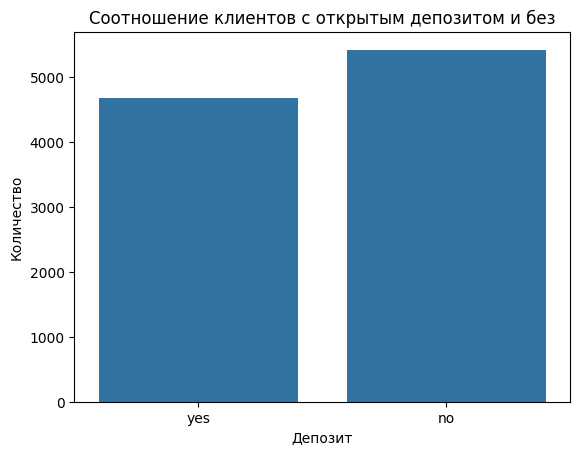

In [64]:
# Построение столбчатой диаграммы
sns.countplot(x='deposit', data=df_cleaned)

# Настройка осей и названия диаграммы
plt.xlabel('Депозит')
plt.ylabel('Количество')
plt.title('Соотношение клиентов с открытым депозитом и без')

# Отображение диаграммы
plt.show()

### Задания 2 и 3

Начнём с описательных статистик для количественных переменных.

* Рассчитайте их и продумайте подробную интерпретацию.
* Попробуйте описать данные, которые у вас есть, увидеть первые зависимости.
* Рассмотрите минимальные и максимальные значения.
* Посмотрите на меры разброса и оцените, насколько данные вариативны.
* Сравнив меры центральной тенденции, сделайте выводы о том, есть ли аномальные значения с меньшей или большей стороны.
* Дополните выводы визуализациями. Вспомните, какие диаграммы могут помочь в иллюстрации распределений количественных данных.

In [65]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код

describe_features =['age','balance', 'day', 'campaign', 'pdays', 'duration', 'previous']

df_cleaned[describe_features].describe()

,age,balance,day,campaign,pdays,duration,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,2.517170,51.319644,368.742603,0.816230
std,11.734931,994.151966,8.441510,2.707159,109.644179,346.651524,2.243795
min,18.000000,-2049.000000,1.000000,1.000000,-1.000000,2.000000,0.000000
25%,32.000000,95.000000,8.000000,1.000000,-1.000000,137.000000,0.000000
50%,38.000000,445.000000,15.000000,2.000000,-1.000000,252.000000,0.000000
75%,48.000000,1227.000000,22.000000,3.000000,2.000000,490.000000,1.000000
max,95.000000,4063.000000,31.000000,43.000000,854.000000,3881.000000,58.000000


У balance, pdays и duration высокое стандартное отклонение, т.е. есть большая вариативность в данных.
Возможные аномалии в данных: есть клиенты с очень большим и отрицательным балансом, есть очень долгие звонки и очень большое кол-во контактов с клиентом.

In [66]:
# преобразование yes-no столбцов в бинарные
for i in df_cleaned.nunique()[df_cleaned.nunique() == 2].index:
    
    df_cleaned[i] = df_cleaned[i].apply(lambda x: 1 if x == 'yes' else 0 if x == 'no' else x)
    
print(df_cleaned.nunique()[df_cleaned.nunique() == 2].index.to_list())
df_for_this_cell = df_cleaned.select_dtypes(include='number')
df_cleaned

['default', 'housing', 'loan', 'deposit']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,0,2343.0,1,0,unknown,5,may,1042,1,-1,0,unknown,1
1,56,admin.,married,secondary,0,45.0,0,0,unknown,5,may,1467,1,-1,0,unknown,1
2,41,technician,married,secondary,0,1270.0,1,0,unknown,5,may,1389,1,-1,0,unknown,1
3,55,services,married,secondary,0,2476.0,1,0,unknown,5,may,579,1,-1,0,unknown,1
4,54,admin.,married,tertiary,0,184.0,0,0,unknown,5,may,673,2,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,0,1.0,1,0,cellular,20,apr,257,1,-1,0,unknown,0
11158,39,services,married,secondary,0,733.0,0,0,unknown,16,jun,83,4,-1,0,unknown,0
11159,32,technician,single,secondary,0,29.0,0,0,cellular,19,aug,156,2,-1,0,unknown,0
11160,43,technician,married,secondary,0,0.0,0,1,cellular,8,may,9,2,172,5,failure,0


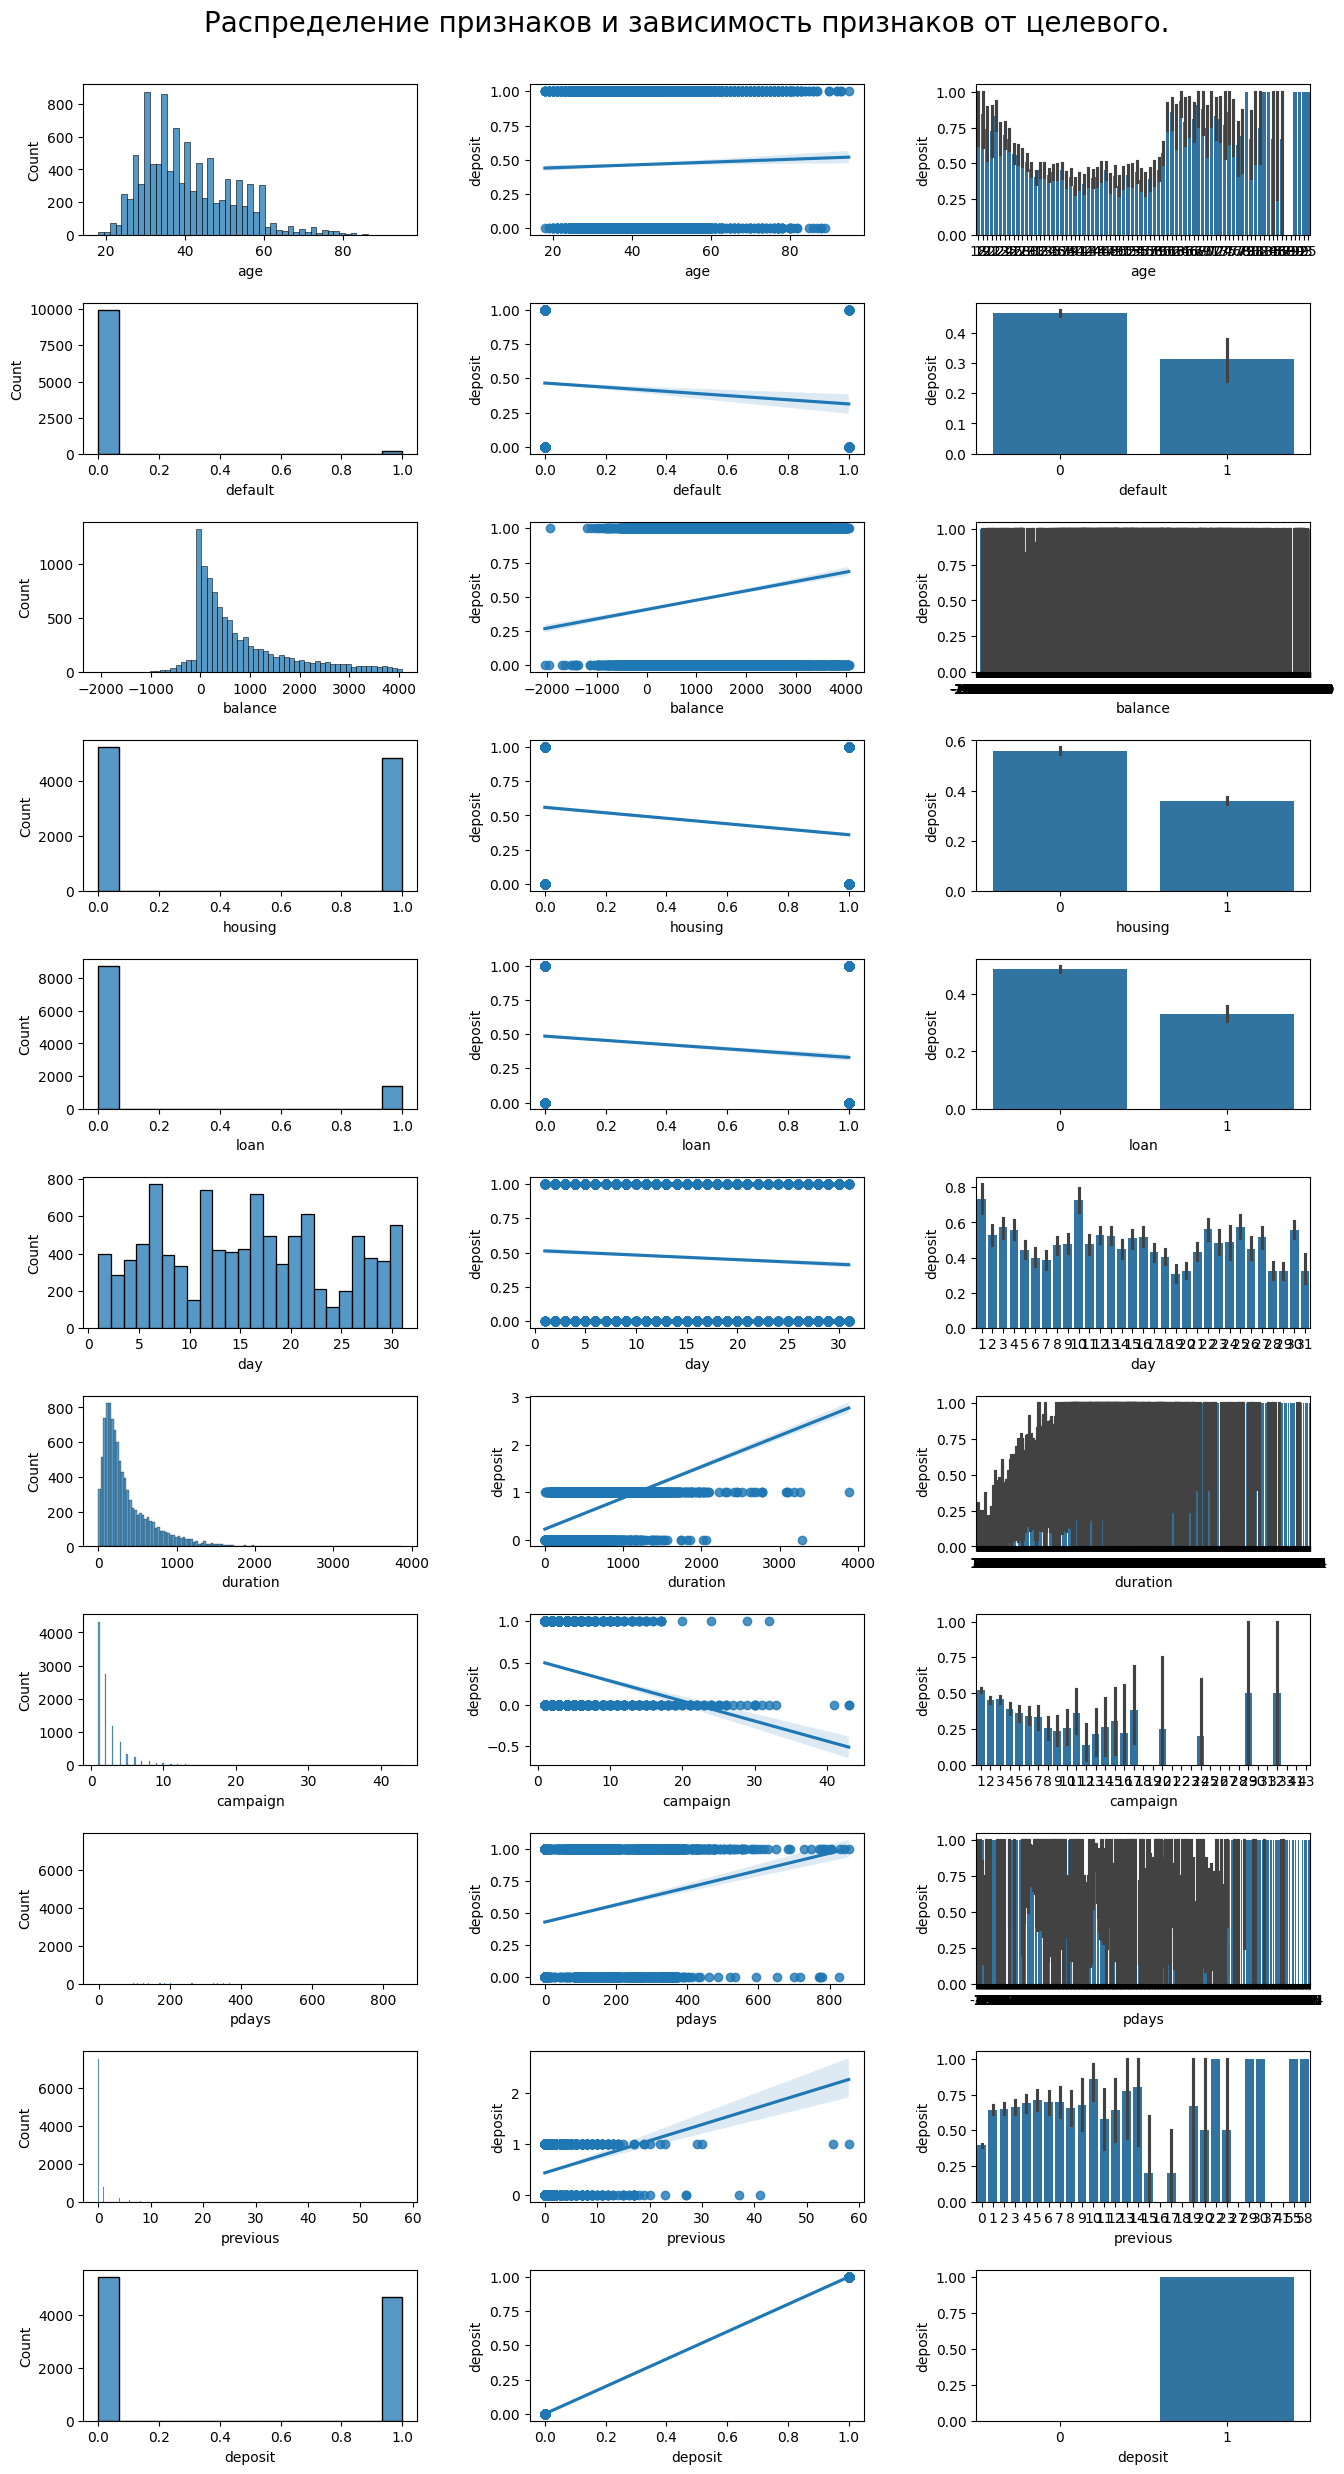

In [67]:

fig, ax = plt.subplots(nrows=len(df_for_this_cell.columns), ncols=3, figsize=(13, 25))

fig.tight_layout(w_pad=5, h_pad=3) # расстояние между подграфиками
plt.subplots_adjust(top=0.95) # чтобы заголовок не налезал на графики

plt.suptitle('Распределение признаков и зависимость признаков от целевого.').set_fontsize(20)

for i, feature in enumerate(df_for_this_cell):
    
    sns.histplot(data=df_for_this_cell, x=feature, ax=ax[i, 0])
    sns.regplot(data=df_for_this_cell, x=feature, y='deposit', ax=ax[i, 1])
    sns.barplot(data=df_for_this_cell, x=feature, y='deposit', ax=ax[i, 2], orient='v')
    

Признаки balance, duration, campain и previous можно назвать логнормальными. У большинства признаков приличная корреляция с целевым. Клиенты с кредитом или ипотекой реже открывают депозит.

### Задания 4 и 5

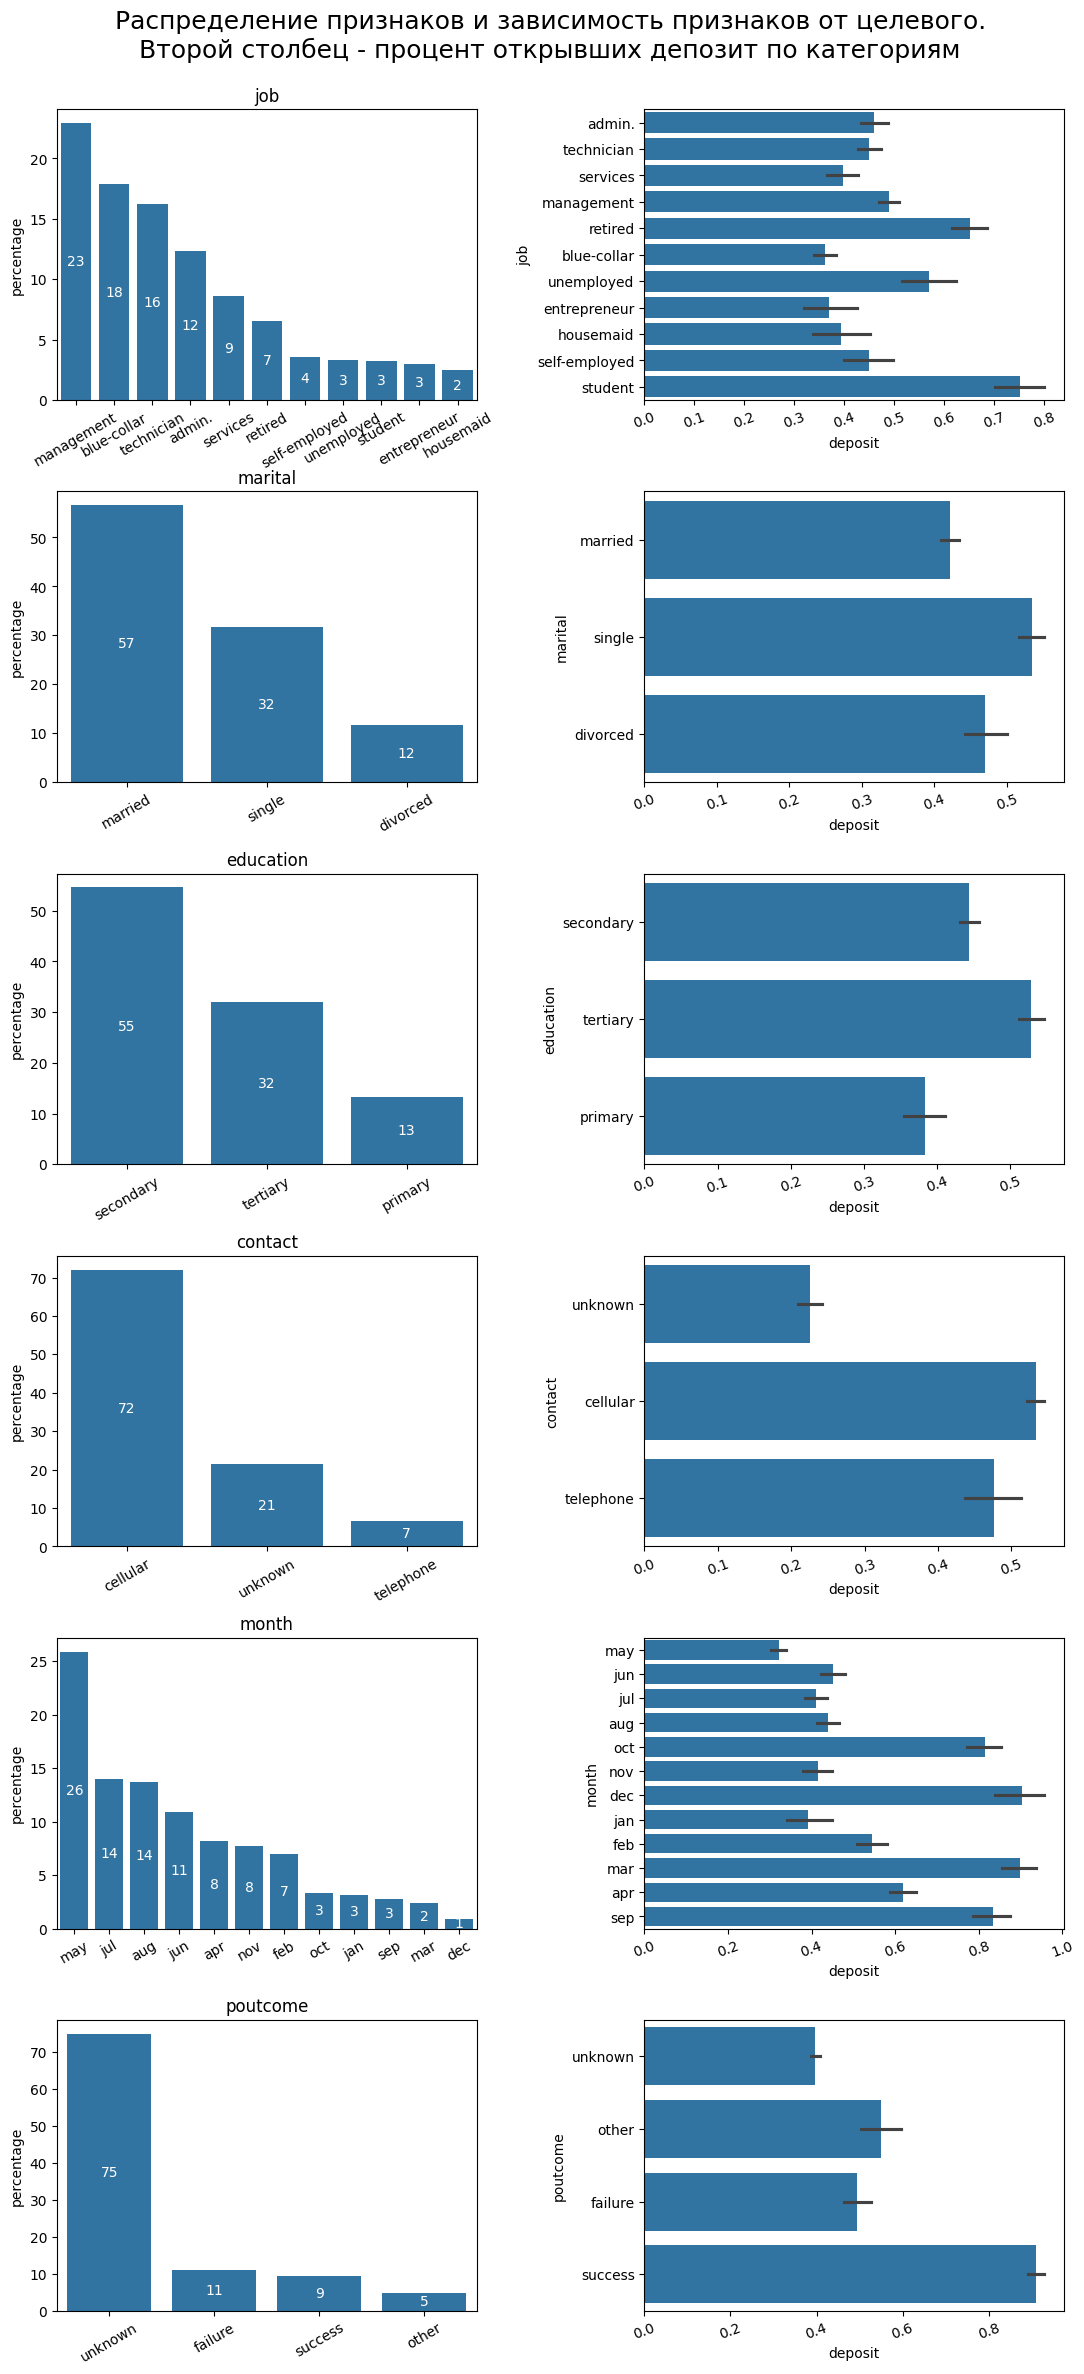

In [68]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты
df_for_this_cell = df_cleaned.select_dtypes(include='object')

fig, ax = plt.subplots(nrows=len(df_for_this_cell.columns), ncols=2, figsize=(13, 25))

plt.suptitle('Распределение признаков и зависимость признаков от целевого.\nВторой столбец - процент открывших депозит по категориям').set_fontsize(18)

fig.tight_layout(pad=9, h_pad=4) # расстояние между подграфиками
plt.subplots_adjust(top=0.94) 

# Создаем цикл для всех признаков из списка категориальных признаков
for i, feature in enumerate(list(df_for_this_cell.columns)):
    
    series_for_this_loop = (df_for_this_cell[feature].value_counts(normalize=True)*100)\
                                                     .sort_values(ascending=False)\
                                                     .rename('percentage')\
                                                     .reset_index()
    
    # Строим количественную столбчатую для долевого соотношения каждой из категорий в данных
    count_barplot = sns.barplot(data=series_for_this_loop, x=series_for_this_loop[feature], y='percentage', ax=ax[i, 0])
    
    count_barplot.xaxis.set_tick_params(rotation=30)
    count_barplot.set_xlabel('')
    count_barplot.set_title(f"{feature}")
    count_barplot.bar_label(count_barplot.containers[0], fmt='%.0f', label_type='center', color='white')
    
    # Строим столбчатую диаграмму доли людей зарабатывающих открывших депозит в зависимости от категории
    mean_barplot = sns.barplot(data=df_cleaned, x='deposit', y=feature, ax=ax[i, 1], orient='h')
    mean_barplot.xaxis.set_tick_params(rotation=20)
    

Больше всего соглашаются на открытие депозита студены, люди в отставке (retired) и безработные. На депозиты больше соглашаются одинокие и разведённые, хотя людей, находящихся в браке больше. Люди с высшим образованием больше склонны открыть депозит. По стационарному телефону люди чаще соглашаются на депозит, чем по мобильному. Чаще всего депозиты открывают в октябре, декабре, марте и сентябре.
В признаке poutcome много неизвестных значений, этот признак необходимо как-то обрабатывать.

### Задание 6

Статус, в котором успехов намного больше, чем неудач: success


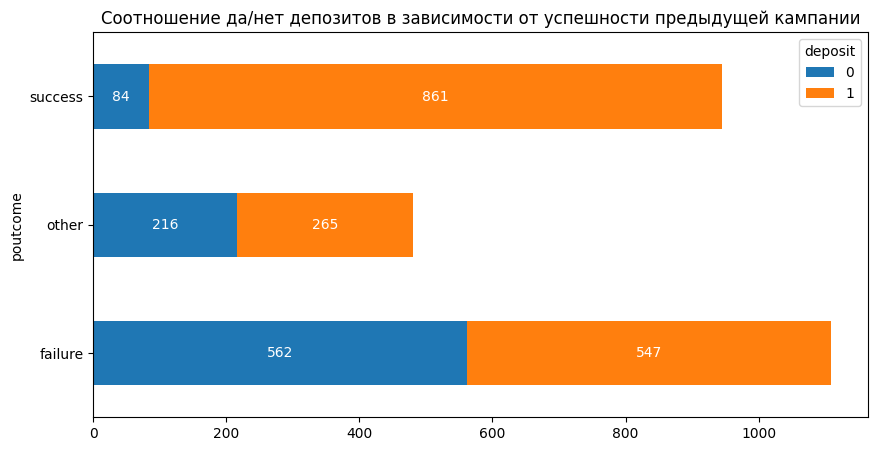

In [69]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код
print(f"Статус, в котором успехов намного больше, чем неудач: {df_cleaned.groupby('poutcome')['deposit'].value_counts().index[4][0]}")

fig, ax = plt.subplots(figsize=(10, 5))
types = df_cleaned.groupby('poutcome')['deposit'].value_counts(normalize=False).unstack().drop('unknown')
types.plot(kind='barh', stacked='True', ax=ax);
[ax.bar_label(ax.containers[i], fmt='%.0f', label_type='center', color='white') for i in range(len(ax.containers))]
ax.set_title('Соотношение да/нет депозитов в зависимости от успешности предыдущей кампании');

Люди, которые уже однажды согласились на предложение банка, более склонны принять его вновь.

### Задание 7

Месяц самого большого процента неудач: may


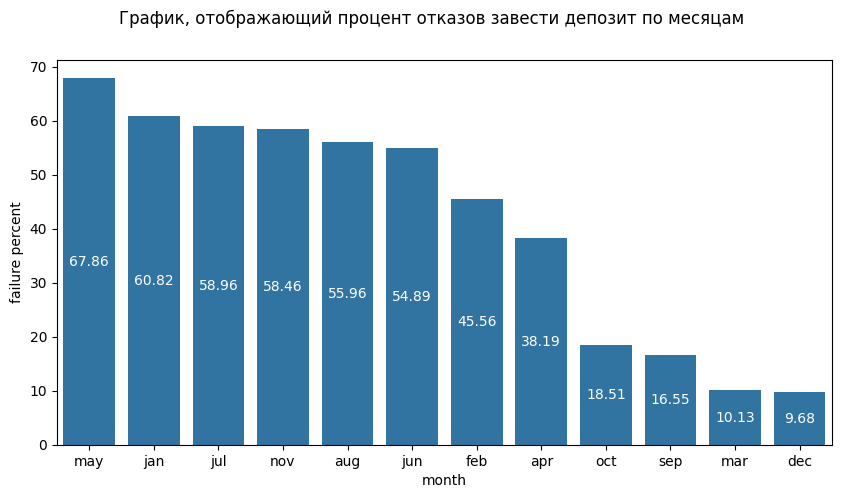

In [70]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
series_for_this_cell = ((df_cleaned[df_cleaned['deposit'] == 0].groupby('month')['deposit'].count() / df_cleaned.groupby('month')['deposit'].count()) * 100).sort_values(ascending=False)

print(f"Месяц самого большого процента неудач: {series_for_this_cell[series_for_this_cell == series_for_this_cell.max()].index[0]}")

fig, ax = plt.subplots(figsize=(10, 5))
plt.suptitle('График, отображающий процент отказов завести депозит по месяцам')
sns.barplot(series_for_this_cell.reset_index(), x='month', y='deposit')
ax.bar_label(ax.containers[0], fmt='%.2f', label_type='center', color='white')
ax.set_ylabel('failure percent');

### Задание 8

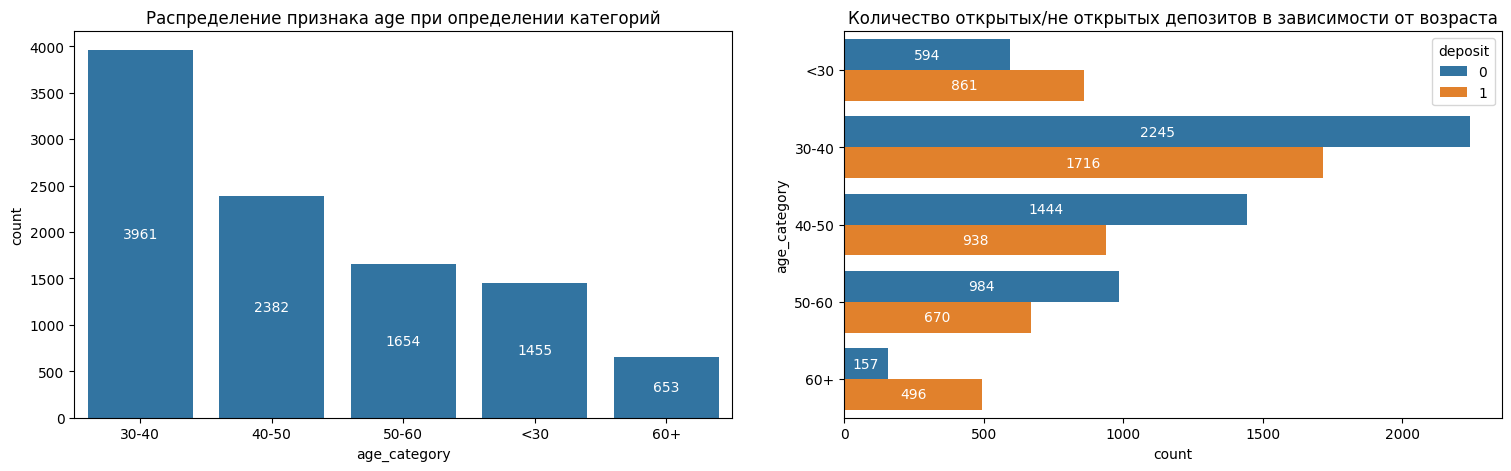

In [71]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения

lambda_for_age = lambda x: \
    '<30' if x < 30 else\
        '30-40' if x >= 30 and x < 40 else\
            '40-50' if x >= 40 and x < 50 else\
                '50-60' if x >= 50 and x < 60 else\
                    '60+' if x >= 60 else x
index_order_age = ['<30', '30-40', '40-50', '50-60', '60+']

df_cleaned['age_category'] = df_cleaned['age'].apply(lambda_for_age)


fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 5))

fig.tight_layout(w_pad=5, h_pad=3) # расстояние между подграфиками
plt.subplots_adjust(top=0.85)
              
sns.barplot(df_cleaned['age_category'].value_counts().reset_index(), x='age_category', y='count', ax=ax[0])
ax[0].bar_label(ax[0].containers[0], fmt='%.0f', label_type='center', color='white')
ax[0].set_title('Распределение признака age при определении категорий')

df_for_second_plot = df_cleaned.groupby(['age_category', 'deposit'])['deposit'].count().unstack().reindex(index_order_age).stack().reset_index(name='count')
sns.barplot(df_for_second_plot, x='count', y='age_category', hue='deposit', ax=ax[1], orient='h')
[ax[1].bar_label(ax[1].containers[i], fmt='%.0f', label_type='center', color='white') for i in range(len(ax[1].containers))];
ax[1].set_title('Количество открытых/не открытых депозитов в зависимости от возраста');

### Задания 9 и 10

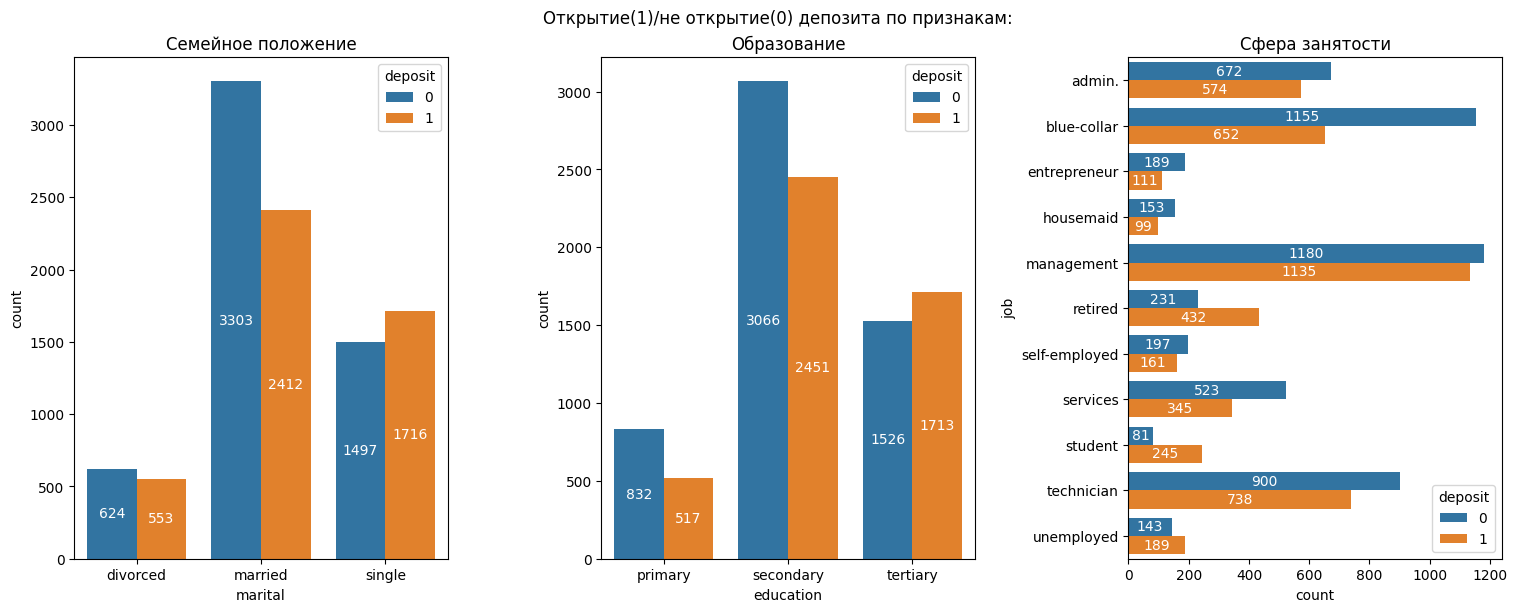

In [72]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
# # постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости


fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(15, 6))

fig.tight_layout(w_pad=8, h_pad=3) # расстояние между подграфиками
plt.subplots_adjust(top=0.9) # чтобы заголовок не налезал на графики

plt.suptitle('Открытие(1)/не открытие(0) депозита по признакам:')

sns.barplot(df_cleaned.groupby(['marital', 'deposit'])['deposit'].count().reset_index(name='count'), x='marital', y='count', hue='deposit', ax=ax[0])
[ax[0].bar_label(ax[0].containers[i], fmt='%.0f', label_type='center', color='white') for i in range(len(ax[0].containers))]
ax[0].set_title('Семейное положение')

sns.barplot(df_cleaned.groupby(['education', 'deposit'])['deposit'].count().reset_index(name='count'), x='education', y='count', hue='deposit', ax=ax[1])
[ax[1].bar_label(ax[1].containers[i], fmt='%.0f', label_type='center', color='white') for i in range(len(ax[1].containers))]
ax[1].set_title('Образование')

sns.barplot(df_cleaned.groupby(['job', 'deposit'])['deposit'].count().reset_index(name='count'), y='job', x='count', hue='deposit', orient='h', ax=ax[2])
[ax[2].bar_label(ax[2].containers[i], fmt='%.0f', label_type='center', color='white') for i in range(len(ax[2].containers))]
ax[2].set_title('Сфера занятости');

### Задание 11

In [73]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
# Разделение таблицы на две части: открытые депозиты и неоткрытые депозиты
opened_deposits = df_cleaned[df_cleaned['deposit'] == 1]
not_opened_deposits = df_cleaned[df_cleaned['deposit'] == 0]

# Создание сводных таблиц для каждой части 
opened_pivot = opened_deposits.pivot_table(index='education', columns='marital', aggfunc='size', fill_value=0)
not_opened_pivot = not_opened_deposits.pivot_table(index='education', columns='marital', aggfunc='size', fill_value=0)

print(opened_pivot)
print(not_opened_pivot)

marital    divorced  married  single
education                           
primary          96      339      82
secondary       283     1289     879
tertiary        174      784     755
marital    divorced  married  single
education                           
primary          91      641     100
secondary       370     1830     866
tertiary        163      832     531


Самыми многочисленными является пересечение категорий: ['married' 'secondary']


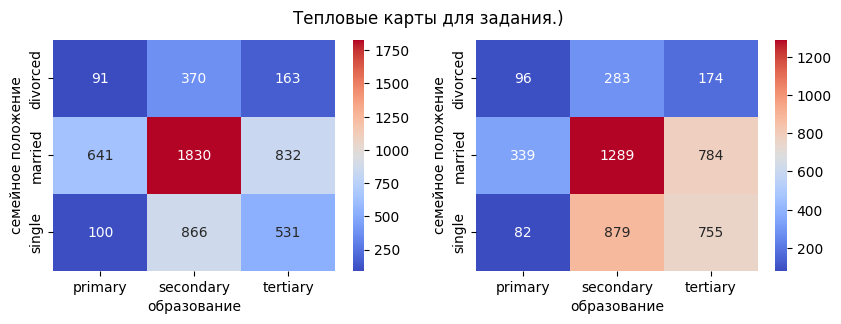

In [74]:
df_for_this_cell = df_cleaned.groupby(['marital', 'education'])['deposit'].count().reset_index()
print(f"Самыми многочисленными является пересечение категорий: {df_for_this_cell[df_for_this_cell['deposit'] == df_for_this_cell['deposit'].max()].drop('deposit', axis=1).values[0]}")

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 3))

plt.suptitle('Тепловые карты для задания.)')

for i in range(len(df_cleaned['deposit'].value_counts())):
    
    temp_df = df_cleaned[df_cleaned['deposit'] == i]
    
    pivot_s2_p11 = temp_df.pivot_table(values='deposit',
                                       index='marital',
                                       columns='education',
                                       aggfunc='count')
    
    sns.heatmap(pivot_s2_p11, annot=True, fmt='.0f', cmap='coolwarm', ax=ax[i])
    ax[i].set_xlabel('образование')
    ax[i].set_ylabel('семейное положение')

## Часть 3: преобразование данных

Перед тем как перейти к построению модели, осталось сделать ещё один шаг.

* Следует помнить, что алгоритмы машинного обучения не могут обрабатывать категориальные признаки в их обычном виде. По ходу работы алгоритм считает показатели (например, средние значения), которые можно вычислить только для количественных признаков. Поэтому нам необходимо преобразовать категориальные признаки в более удобный формат.
* Необходимо масштабировать и трансформировать некоторые признаки для того, чтобы улучшить качество модели.
* Надо отобрать признаки, которые мы будем использовать для обучения модели.

### Задание 1

In [75]:
# преобразуйте уровни образования
df_transformed = df_cleaned.copy()
encoder = LabelEncoder()

# Применение LabelEncoder к признаку "education"
df_transformed['education'] = encoder.fit_transform(df_transformed['education'])
print(df_transformed['education'].sum())
# Применение LabelEncoder к признаку "age_cathegory"
df_transformed['age_category'] = encoder.fit_transform(df_transformed['age_category'])


11995


### Задания 2 и 3

In [76]:
# преобразуйте бинарные переменные в представление из нулей и единиц
# данное преобразование было выполнено ранее
print(f"Стандартное отклонение по переменной deposit: {round(df_transformed['deposit'].std(), 3)}")
print(f"Сумма по трём переменным: {round(df_transformed['default'].mean() + df_transformed['housing'].mean() + df_transformed['loan'].mean(), 3)}")

Стандартное отклонение по переменной deposit: 0.499
Сумма по трём переменным: 0.635


### Задание 4

In [77]:
# создайте дамми-переменные
to_dummy_list = ['job', 'marital', 'contact', 'month', 'poutcome']
df_transformed = pd.concat([df_transformed, pd.get_dummies(df_transformed[to_dummy_list]).astype(int)], axis=1)

print(f"В датасете теперь: {df_transformed.drop('deposit', axis=1).shape[1]} признаков")

В датасете теперь: 50 признаков


### Задания 5 и 6

In [78]:


df_to_corr = df_transformed.drop(['job', 'contact', 'month', 'poutcome', 'marital'], axis=1)

In [79]:
df_to_corr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   education          10105 non-null  int32  
 2   default            10105 non-null  int64  
 3   balance            10105 non-null  float64
 4   housing            10105 non-null  int64  
 5   loan               10105 non-null  int64  
 6   day                10105 non-null  int64  
 7   duration           10105 non-null  int64  
 8   campaign           10105 non-null  int64  
 9   pdays              10105 non-null  int64  
 10  previous           10105 non-null  int64  
 11  deposit            10105 non-null  int64  
 12  age_category       10105 non-null  int32  
 13  job_admin.         10105 non-null  int32  
 14  job_blue-collar    10105 non-null  int32  
 15  job_entrepreneur   10105 non-null  int32  
 16  job_housemaid      10105 no

In [80]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
# Вычисление матрицы корреляций
df_corr = df_to_corr.corr()
result_columns = []
for column in df_corr:
    col_data = df_corr[column]
    if col_data.min() < -0.4 or col_data.sort_values(ascending=False)[1] > 0.4:
        result_columns.append(column)
# result_columns.append('') 
fig, (axes) = plt.subplots(ncols=1, figsize=(30,30), dpi = 300)
sns.heatmap(df_transformed[result_columns].corr(), annot=True, fmt='.2f', ax=axes);
fig.savefig(format('svg.svg'))

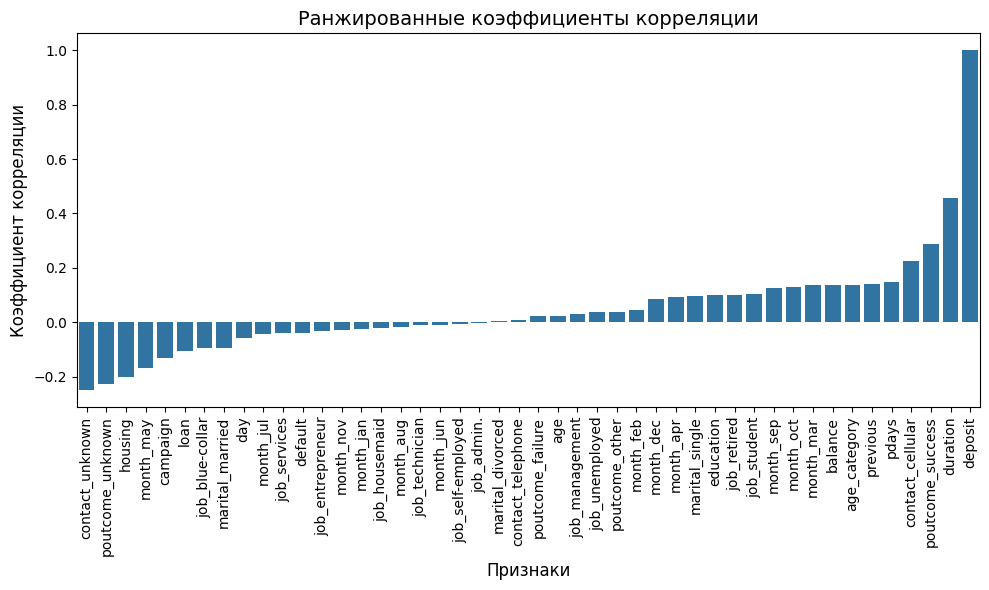

In [81]:
sorted_correlation = df_corr['deposit'].sort_values()

# Создание нового графика с большим размером
plt.figure(figsize=(10, 6))

# Построение столбчатой диаграммы с использованием Seaborn
sns.barplot(x=sorted_correlation.index, y=sorted_correlation)
plt.xticks(rotation=90, fontsize=10)  # Поворот меток по оси x и изменение размера шрифта
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Коэффициент корреляции', fontsize=12)
plt.title('Ранжированные коэффициенты корреляции', fontsize=14)

# Увеличение отступов между столбцами для избежания слияния названий
plt.tight_layout()

plt.show()

In [82]:
# Задание порогового значения корреляции для определения мультиколлинеарности
threshold = 0.9

# Создание пустого списка для хранения пар признаков с сильной корреляцией
multicollinear_features = []

# Перебор всех признаков и их корреляций
for feature in df_corr:
    correlated = df_corr[feature][(df_corr[feature] > threshold) & (df_corr[feature] < 1.0)]
    if not correlated.empty:
        multicollinear_features.append((feature, correlated))
        
# Вывод пар признаков с сильной корреляцией (мультиколлинеарностью)
if multicollinear_features:
    print("Найдена мультиколлинеарность среди следующих признаков:")
    for feature, correlated in multicollinear_features:
        print(f"Признак: {feature}")
        print(f"Сильная корреляция с:")
        print(correlated)
        print("----------------------------------------")
else:
    print("Мультиколлинеарность не обнаружена.")

Мультиколлинеарность не обнаружена.


### Задания 7 и 8

In [83]:
X = df_to_corr.drop(['deposit'], axis=1)
y = df_to_corr['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [84]:
# рассчитайте необходимые показатели
display(X_train.shape)
display(X_test.shape) 

(6770, 45)

(3335, 45)

In [85]:
mean_deposit = y_test.mean()
rounded_mean_deposit = round(mean_deposit, 2)
print(f"Среднее значение целевой переменной на тестовой выборке: {rounded_mean_deposit}")

Среднее значение целевой переменной на тестовой выборке: 0.46


### Задание 9

In [86]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector_k_best = SelectKBest(score_func=f_classif, k=15)

X_train_k_best = pd.DataFrame(selector_k_best.fit_transform(X_train, y_train), columns=selector_k_best.get_feature_names_out())
X_test_k_best = X_test[selector_k_best.get_feature_names_out()]

# Получение индексов выбранных признаков
selected_indices = selector_k_best.get_support(indices=True)
selected_features = X_train.columns[selected_indices]

# Вывод выбранных признаков
print("Выбранные признаки:")
print(selected_features)

Выбранные признаки:
Index(['balance', 'housing', 'duration', 'campaign', 'pdays', 'previous',
       'age_category', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')


### Задание 10

In [87]:
# нормализуйте данные с помощью minmaxsxaler
min_max_scaler_3_10 = preprocessing.MinMaxScaler()
min_max_scaler_3_10.fit(X_train_k_best)

X_train_k_best_norm = min_max_scaler_3_10.transform(X_train_k_best)
X_test_k_best_norm = min_max_scaler_3_10.transform(X_test_k_best)

print(f"Среднее арифметическое для первого предиктора из тестовой выборки: {pd.DataFrame(X_test_k_best_norm).iloc[:, 0].mean().round(2)}")

Среднее арифметическое для первого предиктора из тестовой выборки: 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [88]:
# обучите логистическую регрессию и рассчитайте метрики качества
lgr_4_1 = linear_model.LogisticRegression(solver='sag', max_iter=1000, random_state=42, n_jobs=-1)
lgr_4_1.fit(X_train_k_best_norm, y_train)

print(metrics.classification_report(y_test, lgr_4_1.predict(X_test_k_best_norm)))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1790
           1       0.83      0.73      0.78      1545

    accuracy                           0.80      3335
   macro avg       0.81      0.80      0.80      3335
weighted avg       0.81      0.80      0.80      3335



### Задания 2,3,4

In [89]:
# обучите решающие деревья, настройте максимальную глубину
dtc_4_2 = tree.DecisionTreeClassifier(criterion='entropy', random_state=42)
dtc_4_2.fit(X_train_k_best_norm, y_train)

#Выводим значения метрики 
y_train_pred = dtc_4_2.predict(X_train_k_best_norm)
print('Train:', metrics.classification_report(y_train, y_train_pred))
y_test_pred = dtc_4_2.predict(X_test_k_best_norm)
print('Test:', metrics.classification_report(y_test, y_test_pred))

Train:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3634
           1       1.00      1.00      1.00      3136

    accuracy                           1.00      6770
   macro avg       1.00      1.00      1.00      6770
weighted avg       1.00      1.00      1.00      6770

Test:               precision    recall  f1-score   support

           0       0.76      0.78      0.77      1790
           1       0.74      0.71      0.72      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.74      0.75      3335
weighted avg       0.75      0.75      0.75      3335



Наблюдается переобучение

In [90]:
# обучаем решающие деревья, настраиваем максимальную глубину

#Создаем объект класса дерево решений
dt = tree.DecisionTreeClassifier(
    criterion='entropy',
    #min_samples_leaf=5,
    max_depth=6,
    random_state=42
)
#Обучаем дерево по алгоритму CART
dt.fit(X_train_k_best_norm, y_train)
#Выводим значения метрики 
y_train_pred = dt.predict(X_train_k_best_norm)
print('Train:', metrics.classification_report(y_train, y_train_pred))
y_test_pred = dt.predict(X_test_k_best_norm)
print('Test:', metrics.classification_report(y_test, y_test_pred))

Train:               precision    recall  f1-score   support

           0       0.86      0.79      0.82      3634
           1       0.78      0.85      0.81      3136

    accuracy                           0.82      6770
   macro avg       0.82      0.82      0.82      6770
weighted avg       0.82      0.82      0.82      6770

Test:               precision    recall  f1-score   support

           0       0.85      0.78      0.81      1790
           1       0.77      0.84      0.80      1545

    accuracy                           0.81      3335
   macro avg       0.81      0.81      0.81      3335
weighted avg       0.81      0.81      0.81      3335



### Задание 5

In [91]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV
param_grid = {
              'min_samples_split': [2, 5, 7, 10],
              'max_depth': [3,5,7]
              }

grid_search = GridSearchCV(estimator=tree.DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=5)

grid_search.fit(X_train_k_best_norm, y_train)

%time grid_search.fit(X_train_k_best_norm, y_train) 

print(f"accuracy на тестовом наборе: {grid_search.score(X_test_k_best_norm, y_test):.2f}")
y_test_pred = grid_search.predict(X_test_k_best_norm)
print(f'f1_score на тестовом наборе: {metrics.f1_score(y_test, y_test_pred):.2f}')
print(f"Наилучшие значения гиперпараметров: {grid_search.best_params_}")

CPU times: total: 1.12 s
Wall time: 1.13 s
accuracy на тестовом наборе: 0.81
f1_score на тестовом наборе: 0.80
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 2}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [92]:
# обучите на ваших данных случайный лес
rf_5_1 = ensemble.RandomForestClassifier(n_estimators=100,
                                         criterion='gini',
                                         min_samples_leaf=5,
                                         max_depth=10,
                                         random_state=42,
                                         n_jobs=-1)
rf_5_1.fit(X_train_k_best_norm, y_train)

print(metrics.classification_report(y_test, rf_5_1.predict(X_test_k_best_norm)))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3

In [93]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
gbc_5_2 = ensemble.GradientBoostingClassifier(learning_rate=0.05,
                                              n_estimators=300,
                                              min_samples_leaf=5,
                                              max_depth=5,
                                              random_state=42)
gbc_5_2.fit(X_train_k_best_norm, y_train)

print(metrics.classification_report(y_test, gbc_5_2.predict(X_test_k_best_norm)))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



Результаты применения градиентного бустинга и случайного леса одинаковы.

### Задание 4

In [94]:
# объедините уже известные вам алгоритмы с помощью стекинга 
estimators_5_4 = [('lr', linear_model.LogisticRegression(solver='sag', max_iter=1000, random_state=42, n_jobs=-1)),
                  ('dtc', tree.DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_split=10, random_state=42)),
                  ('gbc', ensemble.GradientBoostingClassifier(learning_rate=0.05,
                                                              n_estimators=300,
                                                              min_samples_leaf=5,
                                                              max_depth=5,
                                                              random_state=42))]

stacking_5_4 = ensemble.StackingClassifier(estimators=estimators_5_4,
                                           final_estimator=linear_model.LogisticRegression(random_state=42, n_jobs=-1))

stacking_5_4.fit(X_train_k_best_norm, y_train)

print(metrics.classification_report(y_test, stacking_5_4.predict(X_test_k_best_norm)))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1790
           1       0.80      0.81      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335



### Задание 5

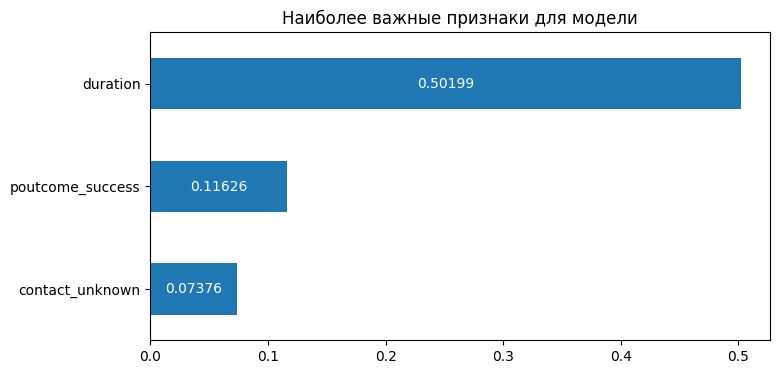

In [95]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга
fig, ax = plt.subplots(figsize=(8, 4))
pd.DataFrame(gbc_5_2.feature_importances_, index=X_train_k_best.columns).sort_values(by=0).tail(3).plot(kind='barh', legend=False, ax=ax)
ax.bar_label(ax.containers[0], fmt='%.5f', label_type='center', color='white')
ax.set_title('Наиболее важные признаки для модели');

### Задания 6,7,8

In [96]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
def optuna_rf(trial, X, y, param_dict, cross_val=False, cv=5, random_state=42):
    
    # задаем пространства поиска гиперпараметров
    func_params_dict = {}
    
    for i, j in param_dict.items():
        if 'low' in j:
            func_params_dict[i] = trial.suggest_int(**param_dict[i])
        elif 'choices' in j:
            func_params_dict[i] = trial.suggest_categorical(**param_dict[i])
    
    # создаем модель
    model = ensemble.RandomForestClassifier(**func_params_dict, n_jobs=-1, random_state=random_state)
    
    if not cross_val:
        # обучаем модель
        model.fit(X, y)
        score = f1_score(y, model.predict(X))
    else:
        # проводим кросс-валидацию  
        score = cross_val_score(estimator=model, X=X, y=y, 
                                scoring='f1', cv=cv, n_jobs=-1).mean()

    return score

In [97]:
import optuna
from functools import partial
from sklearn.model_selection import StratifiedKFold, cross_val_score
param_dict_5_6 = {'n_estimators': {'name': 'n_estimators', 'low': 100, 'high': 200, 'step': 1},
                  'max_depth': {'name': 'max_depth', 'low': 10, 'high': 30, 'step': 1},
                  'min_samples_leaf': {'name': 'min_samples_leaf', 'low': 2, 'high': 10, 'step': 1}}

# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study_5_6 = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study_5_6.optimize(partial(optuna_rf, 
                           X=X_train_k_best_norm, y=y_train, 
                           param_dict=param_dict_5_6,
                           cross_val=True,
                           cv=StratifiedKFold(n_splits=7, shuffle=True, random_state=42),
                           random_state=42), n_trials=50, show_progress_bar=True)

# выводим результаты на обучающей выборке
print(f"Наилучшие значения гиперпараметров {study_5_6.best_params}")
print(f"f1_score на обучающем наборе: {study_5_6.best_value:.2f}")

model_optuna_5_6 = ensemble.RandomForestClassifier(**study_5_6.best_params,
                                                   random_state=42,
                                                   n_jobs=-1)
model_optuna_5_6.fit(X_train_k_best_norm, y_train)

print(metrics.classification_report(y_test, model_optuna_5_6.predict(X_test_k_best_norm)))

[I 2025-07-06 20:43:23,680] A new study created in memory with name: RandomForestClassifier


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-07-06 20:43:30,252] Trial 0 finished with value: 0.8238745774370054 and parameters: {'n_estimators': 164, 'max_depth': 24, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8238745774370054.
[I 2025-07-06 20:43:33,712] Trial 1 finished with value: 0.8228287978995258 and parameters: {'n_estimators': 160, 'max_depth': 10, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8238745774370054.
[I 2025-07-06 20:43:37,479] Trial 2 finished with value: 0.8244140524551256 and parameters: {'n_estimators': 129, 'max_depth': 22, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.8244140524551256.
[I 2025-07-06 20:43:40,745] Trial 3 finished with value: 0.8227550137861599 and parameters: {'n_estimators': 135, 'max_depth': 25, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.8244140524551256.
[I 2025-07-06 20:43:45,404] Trial 4 finished with value: 0.8227563201480447 and parameters: {'n_estimators': 198, 'max_depth': 28, 'min_samples_leaf': 6}. Best is trial 2 with value: 0.824

In [98]:
print(metrics.classification_report(y_test, model_optuna_5_6.predict(X_test_k_best_norm)))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1790
           1       0.80      0.84      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.82      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



## Вывод:

1. Логистическая регрессия показала хорошие результаты, но немного уступает другим моделям в точности предсказания.

2. Решающие деревья и случайный лес демонстрируют хорошую обобщающую способность и стабильность показателей на тестовой выборке.

3. Градиентный бустинг показал отличные результаты, обладая высокой точностью и F1-мерой как на тренировочной, так и на тестовой выборке.

4. Стекинг моделей позволяет объединить преимущества различных моделей и достичь хорошего качества классификации.

5. Модель с оптимизацией гиперпараметров с помощью Optuna показала приемлемое качество.

Все модели демонстрируют неплохое качество классификации. 